Цель: Научиться применять методы предобработки данных на реальном датасете, оценивать их влияние на качество модели и понимать важность каждого этапа.

Дтасет Bank Marketing Dataset

Ссылка для примера: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing

Целевая переменная: deposit (будет ли клиент открывать депозит).



**Важное условие:** С самого начала разделите исходные данные на обучающую (train) и тестовую (test) выборки в соотношении 80/20. Используйте параметр random_state=42 для воспроизводимости. Все этапы предобработки (заполнение пропусков, кодирование, масштабирование, PCA) должны настраиваться/обучаться ТОЛЬКО на обучающей выборке, а затем применяться к тестовой. Это критически важно для корректной оценки. За основную модель возьмите Random Forest Classifier

1. Базовый анализ (1 балл)

- Загрузите данные, разделите на train/test

- Проведите разведочный анализ данных, посмотрите распределение целевой переменной

- Обучите модель на числовых признаках без обработки (baseline) и на тестовой выборке оцените accuracy


In [34]:
import pandas as pd

In [35]:
import kagglehub
path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")
import os
for file in os.listdir(path):
    if file.endswith('.csv'):
        df = pd.read_csv(os.path.join(path, file), sep=';')
        print(f"Загружен файл: {file}")
        break

Using Colab cache for faster access to the 'bank-marketing' dataset.
Загружен файл: bank-additional-full.csv


In [36]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [37]:
if "deposit" not in df.columns:
    if "y" in df.columns:
        df = df.rename(columns={"y": "deposit"})
    else:
        raise ValueError(f"Нет целевой колонки deposit/y. Имеющиеся колонки: {df.columns.tolist()}")

In [38]:
print("Shape:", df.shape)
display(df.head())

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,deposit
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [39]:
print("\nТипы колонок:")
display(df.dtypes)


Типы колонок:


,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [40]:
print("\nПропуски (NaN) по колонкам (топ-15):")
display(df.isna().sum().sort_values(ascending=False).head(15))


Пропуски (NaN) по колонкам (топ-15):


,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


Явных NaN в данных нет.

In [41]:
cat_cols = df.select_dtypes(include="object").columns.drop("deposit", errors="ignore")
display(((df[cat_cols] == "unknown").sum()).sort_values(ascending=False).head(15))

,0
default,8597
education,1731
housing,990
loan,990
job,330
marital,80
contact,0
month,0
day_of_week,0
poutcome,0


Зато в ячейках есть значения unknown.

In [42]:
print("\nРаспределение целевой переменной:")
target_counts = df["deposit"].value_counts(dropna=False)
display(target_counts.to_frame("count"))
display((target_counts / len(df)).to_frame("share"))


Распределение целевой переменной:


,count
deposit,
no,36548
yes,4640


,share
deposit,
no,0.887346
yes,0.112654


In [43]:
y = df["deposit"]
if y.dtype == "object":
    y = y.map({"no": 0, "yes": 1})
    if y.isna().any():
        raise ValueError("В deposit есть значения не из {yes, no}")

In [44]:
X = df.drop(columns=["deposit"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

def unknown_to_nan(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    obj_cols = X.select_dtypes(include="object").columns
    X[obj_cols] = X[obj_cols].replace("unknown", np.nan)
    return X

X_train = unknown_to_nan(X_train)
X_test  = unknown_to_nan(X_test)

print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nРаспределение таргета (train):")
display(y_train.value_counts().to_frame("count"))
display((y_train.value_counts(normalize=True)).to_frame("share"))



Train shape: (32950, 20)  Test shape: (8238, 20)

Распределение таргета (train):


,count
deposit,
0,29238
1,3712


,share
deposit,
0,0.887344
1,0.112656


In [45]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
print("Числовые признаки:", num_cols)

Числовые признаки: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [46]:
X_train_num = X_train[num_cols]
X_test_num  = X_test[num_cols]

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_num, y_train)
pred = rf.predict(X_test_num)

acc = accuracy_score(y_test, pred)
print(f"Baseline accuracy (только числовые, без обработки): {acc:.4f}")

Baseline accuracy (только числовые, без обработки): 0.9172


2. Обработка пропусков (2 балла)

- Найдите и заполните пропуски в train (2 способами):
  - Удаление строк с пропусками
  - Замена пропусков на медиану (для числовых) или моду (для категориальных).

- Обучите модель на данных без пропусков и на тестовой выборке оцените accuracy

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [48]:
def unknown_to_nan(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    obj_cols = X.select_dtypes(include="object").columns
    X[obj_cols] = X[obj_cols].replace("unknown", np.nan)
    return X

X_train_u = unknown_to_nan(X_train)
X_test_u  = unknown_to_nan(X_test)

num_cols = X_train_u.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_u.select_dtypes(include=["object"]).columns.tolist()

print("num:", num_cols)
print("cat:", cat_cols)

num: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
cat: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [49]:
train_mask = X_train_u.notna().all(axis=1)
test_mask  = X_test_u.notna().all(axis=1)

Xtr_drop = X_train_u.loc[train_mask]
ytr_drop = y_train.loc[train_mask]

Xte_drop = X_test_u.loc[test_mask]
yte_drop = y_test.loc[test_mask]

print("После dropna:", Xtr_drop.shape, Xte_drop.shape)

preprocess_drop = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

model_drop = Pipeline(steps=[
    ("preprocess", preprocess_drop),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

model_drop.fit(Xtr_drop, ytr_drop)
pred_drop = model_drop.predict(Xte_drop)

acc_drop = accuracy_score(yte_drop, pred_drop)
print(f"После dropna accuracy (на test без пропусков): {acc_drop:.4f}")


После dropna: (24305, 20) (6183, 20)
После dropna accuracy (на test без пропусков): 0.9115


In [50]:
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_imp = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop"
)

model_imp = Pipeline(steps=[
    ("preprocess", preprocess_imp),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

model_imp.fit(X_train_u, y_train)
pred_imp = model_imp.predict(X_test_u)

acc_imp = accuracy_score(y_test, pred_imp)
print(f"После замены на median/mode accuracy (полный test): {acc_imp:.4f}")


После замены на median/mode accuracy (полный test): 0.9184


Удаление строк с пропусками заметно сокращает выборку и ухудшает качество (accuracy 0.9115 на сокращённом test).

Замена на median/mode сохраняет объём данных и показывает лучшее качество (accuracy 0.9184 на полном test), поэтому предпочтительнее этот вариант.

3. Кодирование категориальных признаков (2 балла)
- Используй данные полученные 2  методом и далее во всех задачах

- Примените Label Encoding и One-Hot Encoding

- Обучите модель с закодированными признаками и на тестовой выборке оцените accuracy



In [51]:
from sklearn.preprocessing import OrdinalEncoder

In [52]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe_label = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocess_label = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe_label, cat_cols),
])

model_label = Pipeline([
    ("preprocess", preprocess_label),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

model_label.fit(X_train_u, y_train)
pred_label = model_label.predict(X_test_u)
acc_label = accuracy_score(y_test, pred_label)
print(f"После LABEL/ORDINAL encoding accuracy: {acc_label:.4f}")


После LABEL/ORDINAL encoding accuracy: 0.9215


In [53]:
cat_pipe_ohe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_ohe = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe_ohe, cat_cols),
])

model_ohe = Pipeline([
    ("preprocess", preprocess_ohe),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

model_ohe.fit(X_train_u, y_train)
pred_ohe = model_ohe.predict(X_test_u)
acc_ohe = accuracy_score(y_test, pred_ohe)
print(f"После One-Hot encoding accuracy: {acc_ohe:.4f}")

После One-Hot encoding accuracy: 0.9184


Хотя One-Hot обычно считается более корректным, т.к. не навязывает порядок, у деревьев порядок не так критичен, и на практике Label/Ordinal иногда действительно даёт лучшее качество.

4. Обработка выбросов (2 балла )
- Визуализируйте выбросы с помощью boxplot для числовых признаков.

- Примените метод IQR для обнаружения и обработки выбросов .

- Обучите модель на данных без выбросов и на тестовой выборке оцените accuracy


In [54]:
import matplotlib.pyplot as plt

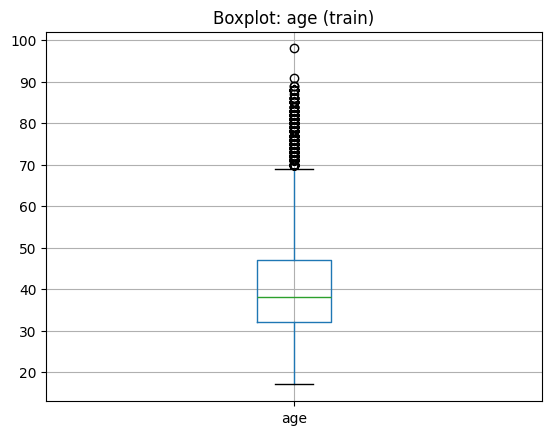

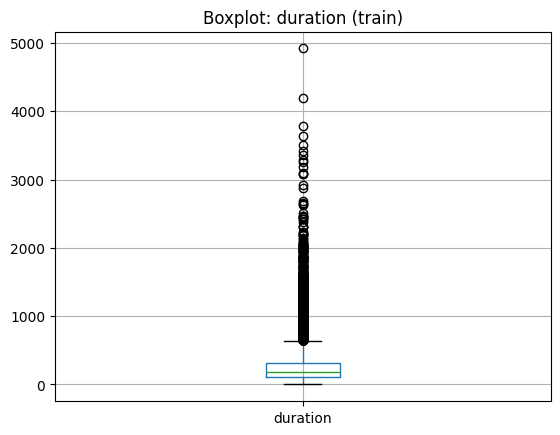

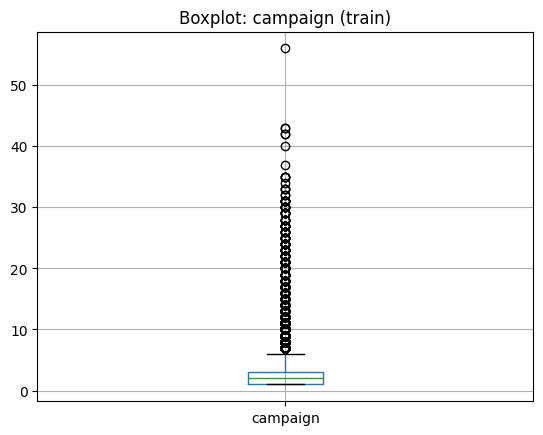

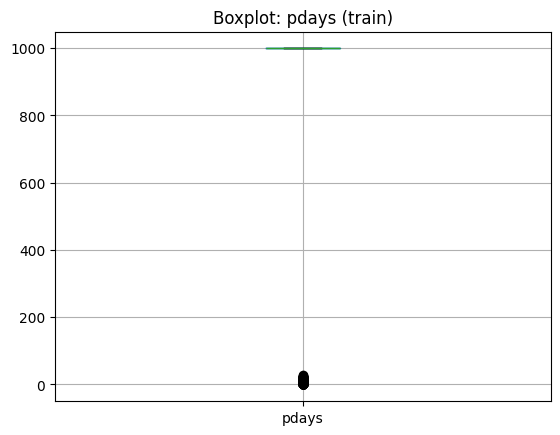

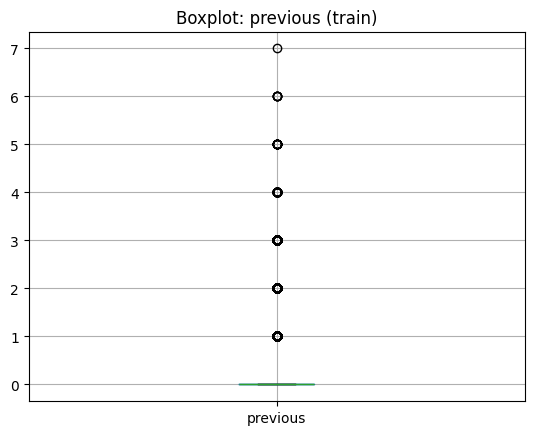

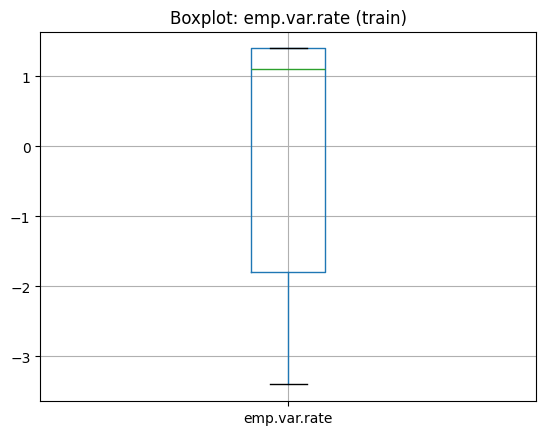

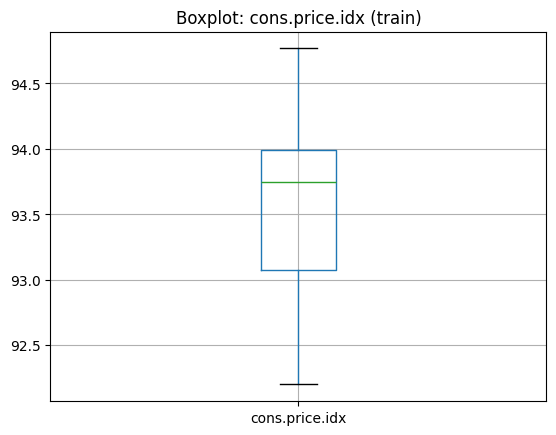

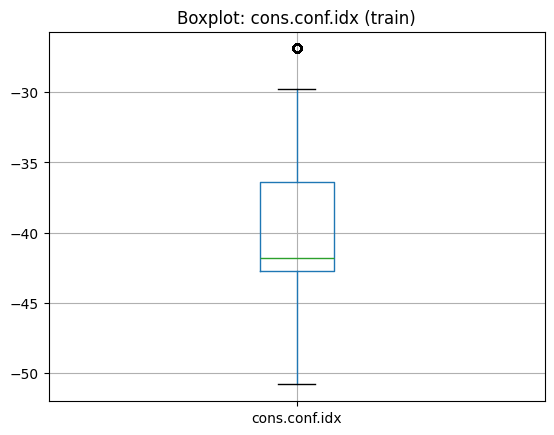

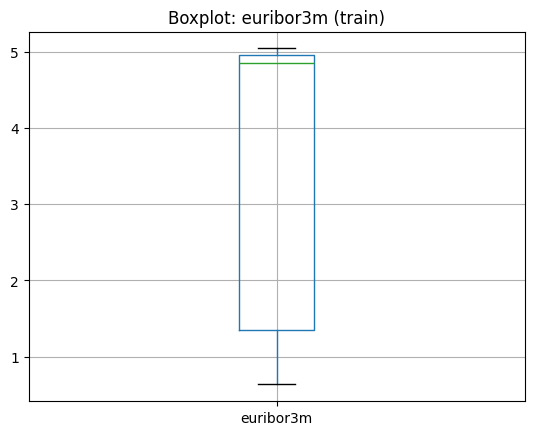

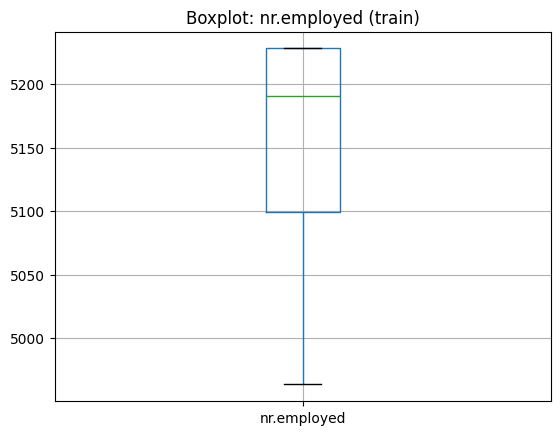

In [55]:
Xtr = X_train_u.copy()

for col in num_cols:
    plt.figure()
    Xtr[[col]].boxplot()
    plt.title(f"Boxplot: {col} (train)")
    plt.show()

In [56]:
def iqr_bounds(series: pd.Series, k: float = 1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - k * iqr
    high = q3 + k * iqr
    return low, high

bounds = {}
for col in num_cols:
    low, high = iqr_bounds(X_train_u[col].dropna(), k=1.5)
    bounds[col] = (low, high)

def clip_outliers_iqr(X: pd.DataFrame, bounds: dict):
    X = X.copy()
    for col, (low, high) in bounds.items():
        X[col] = X[col].clip(lower=low, upper=high)
    return X

X_train_clip = clip_outliers_iqr(X_train_u, bounds)
X_test_clip  = clip_outliers_iqr(X_test_u, bounds)

In [57]:
clipped_counts = {}
for col in num_cols:
    low, high = bounds[col]
    clipped_counts[col] = int(((X_train_u[col] < low) | (X_train_u[col] > high)).sum())

pd.Series(clipped_counts).sort_values(ascending=False).head(10)


,0
previous,4534
duration,2366
campaign,1916
pdays,1226
age,368
cons.conf.idx,359
emp.var.rate,0
cons.price.idx,0
euribor3m,0
nr.employed,0


In [58]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe_label = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe_label, cat_cols),
])

model = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

model.fit(X_train_clip, y_train)
pred = model.predict(X_test_clip)
acc = accuracy_score(y_test, pred)

print(f"После IQR accuracy: {acc:.4f}")

После IQR accuracy: 0.9205


Метод IQR выявил значительное число выбросов в признаках previous, duration, campaign, pdays.

Для RandomForest обработка выбросов почти не улучшила качество (accuracy слегка снизилась). Это нормально: деревья обычно довольно устойчивы к выбросам, а обрезка может убрать полезную информацию в хвостах распределений.

5. Масштабирование признаков (2 балла)

- Примените StandardScaler или MinMaxScaler только к train выборке

- Обучите модель на данных с масштабированными признаками и на тестовой выборке оцените accuracy


In [59]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [60]:
num_pipe_std = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocess_std = ColumnTransformer([
    ("num", num_pipe_std, num_cols),
    ("cat", cat_pipe, cat_cols),
])

model_std = Pipeline([
    ("preprocess", preprocess_std),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

model_std.fit(X_train_u, y_train)
pred_std = model_std.predict(X_test_u)
acc_std = accuracy_score(y_test, pred_std)
print(f"После StandardScaler accuracy: {acc_std:.4f}")


После StandardScaler accuracy: 0.9217


In [61]:
num_pipe_mm = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

preprocess_mm = ColumnTransformer([
    ("num", num_pipe_mm, num_cols),
    ("cat", cat_pipe, cat_cols),
])

model_mm = Pipeline([
    ("preprocess", preprocess_mm),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

model_mm.fit(X_train_u, y_train)
pred_mm = model_mm.predict(X_test_u)
acc_mm = accuracy_score(y_test, pred_mm)
print(f"После MinMaxScaler accuracy: {acc_mm:.4f}")

После MinMaxScaler accuracy: 0.9215


Для RandomForest масштабирование не оказывает существенного влияния на accuracy, т.к. деревья принимают решения по порогам и слабо зависят от масштаба признаков.

Незначительное отличие StandardScaler — это шум/малый эффект, а не принципиальное улучшение.

6. Итоги (1 балл)

- Сравните модели и создайте таблицу с accuracy всех моделей.
- Сделайте выводы

In [62]:
results = [
    ("Baseline (только числовые, без обработки)", 0.9172),
    ("Пропуски: DROP (удаление строк с NaN/unknown) *урезанный test*", 0.9115),
    ("Пропуски: IMPUTE (median/mode) + OHE", 0.9184),
    ("Кодирование: Ordinal (Label для признаков) + IMPUTE", 0.9215),
    ("Выбросы: IQR-CLIP (на числовых) + Ordinal + IMPUTE", 0.9205),
    ("Масштабирование: StandardScaler (num) + Ordinal + IMPUTE", 0.9217),
    ("Масштабирование: MinMaxScaler (num) + Ordinal + IMPUTE", 0.9215),
]

df_res = pd.DataFrame(results, columns=["Модель/предобработка", "Accuracy"]).sort_values("Accuracy", ascending=False)
display(df_res)

,Модель/предобработка,Accuracy
5,Масштабирование: StandardScaler (num) + Ordina...,0.9217
3,Кодирование: Ordinal (Label для признаков) + I...,0.9215
6,Масштабирование: MinMaxScaler (num) + Ordinal ...,0.9215
4,Выбросы: IQR-CLIP (на числовых) + Ordinal + IM...,0.9205
2,Пропуски: IMPUTE (median/mode) + OHE,0.9184
0,"Baseline (только числовые, без обработки)",0.9172
1,Пропуски: DROP (удаление строк с NaN/unknown) ...,0.9115


В датасете нет NaN, но значения unknown являются скрытыми пропусками, поэтому их следует трактовать как пропуски и обрабатывать.

Удаление строк с пропусками сильно уменьшает выборку (и test тоже), поэтому качество падает (0.9115) и результат хуже сопоставим с оценкой на полном test.

Замена на median/mode сохраняет объём данных и даёт лучшее качество (0.9184), поэтому предпочтительнее удаления.

Для категориальных признаков в RandomForest Ordinal/Label-кодирование показало себя лучше One-Hot (0.9215 vs 0.9184) — вероятно из-за меньшей размерности и того, что деревья устойчиво работают с целочисленными кодами.

Обработка выбросов через IQR-clip не улучшила качество и даже слегка снизила (0.9205), что типично для деревьев (они относительно устойчивы к выбросам).

Масштабирование (Standard/MinMax) практически не влияет на RandomForest: изменения минимальны (0.9217 / 0.9215), т.к. деревья мало зависят от масштаба признаков.

Лучшая полученная конфигурация: IMPUTE + Ordinal + StandardScaler с accuracy 0.9217 (разница с 0.9215 очень мала).